Add additional dense layers: Increase the number of dense layers in the model. This can provide more capacity for learning complex relationships in the data. You can add one or more Dense layers with increased number of units.

Here's an example of how you can modify your model to increase its complexity by adding more convolutional and dense layers:

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from google.colab import files


In [9]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Set the file paths for train and test data
file_path = '/content/drive/MyDrive/cell_images'
test_path = file_path + "/test/"
train_path = file_path + "/train/"


In [4]:

# Define the filepath where you want to save the model weights
checkpoint_filepath = '/content/drive/MyDrive/model_checkpoints/model_{epoch:02d}.h5'


In [5]:

# Load the data using ImageDataGenerator
data_generator = ImageDataGenerator(rescale=1./255)

train_data = data_generator.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

test_data = data_generator.flow_from_directory(
    test_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)


Found 24998 images belonging to 2 classes.
Found 2600 images belonging to 2 classes.


In [6]:
# Define the ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,  # Only save the weights, not the entire model
    save_best_only=False,    # Save weights after each epoch
    monitor='val_accuracy',  # Monitor validation accuracy for saving the best weights
    mode='max',              # Mode of monitoring ('max' or 'min')
    save_freq='epoch'        # Save after each epoch
)


In [7]:

# Define the model architecture
model = tf.keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(2, activation='softmax')
])


In [10]:
model.load_weights('/content/drive/MyDrive/model_checkpoints/model_40.h5')


In [11]:

# Set up callbacks for early stopping and learning rate scheduling
# early_stopping = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=2)

In [12]:

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [13]:

# Train the model with data augmentation and callbacks
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    initial_epoch=40,  # Start from epoch 40

    callbacks= [
        # early_stopping,
      lr_scheduler,
      checkpoint_callback]
)



Epoch 41/50
782/782 [==============================] - 5863s 7s/step - loss: 0.0442 - accuracy: 0.9842 - val_loss: 0.1560 - val_accuracy: 0.9581 - lr: 0.0010
Epoch 42/50
782/782 [==============================] - 409s 523ms/step - loss: 0.0378 - accuracy: 0.9866 - val_loss: 0.1486 - val_accuracy: 0.9558 - lr: 0.0010
Epoch 43/50
782/782 [==============================] - 408s 522ms/step - loss: 0.0373 - accuracy: 0.9876 - val_loss: 0.1424 - val_accuracy: 0.9596 - lr: 0.0010
Epoch 44/50
782/782 [==============================] - 395s 506ms/step - loss: 0.0381 - accuracy: 0.9869 - val_loss: 0.1815 - val_accuracy: 0.9585 - lr: 0.0010
Epoch 45/50
782/782 [==============================] - 408s 522ms/step - loss: 0.0349 - accuracy: 0.9880 - val_loss: 0.1614 - val_accuracy: 0.9581 - lr: 0.0010
Epoch 46/50
782/782 [==============================] - 413s 528ms/step - loss: 0.0255 - accuracy: 0.9916 - val_loss: 0.1620 - val_accuracy: 0.9612 - lr: 1.0000e-04
Epoch 47/50
782/782 [=================

In [14]:

# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_data)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


82/82 [==============================] - 16s 192ms/step - loss: 0.1632 - accuracy: 0.9600
Test Loss: 0.16319015622138977
Test Accuracy: 0.9599999785423279


In [15]:

# Retrieve the accuracy from the training history
test_accuracy = history.history['val_accuracy']
print("Test Accuracy from History:", test_accuracy[-1])


Test Accuracy from History: 0.9599999785423279


In [16]:
# Retrieve the training and validation metrics from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


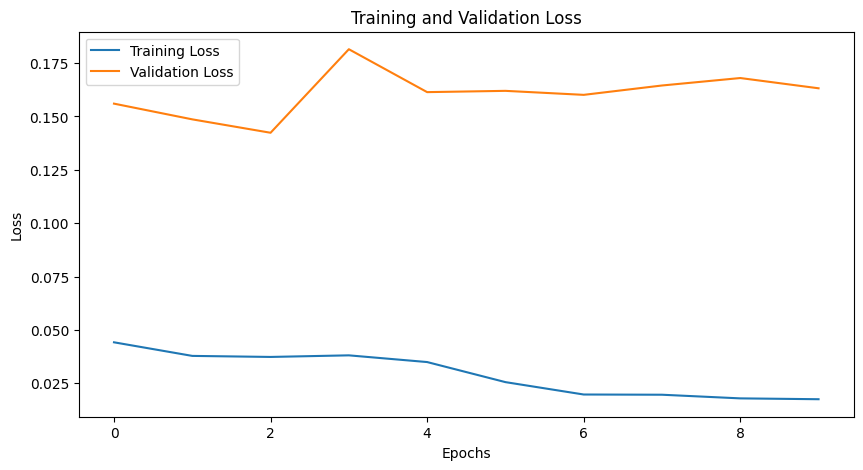

In [17]:

# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


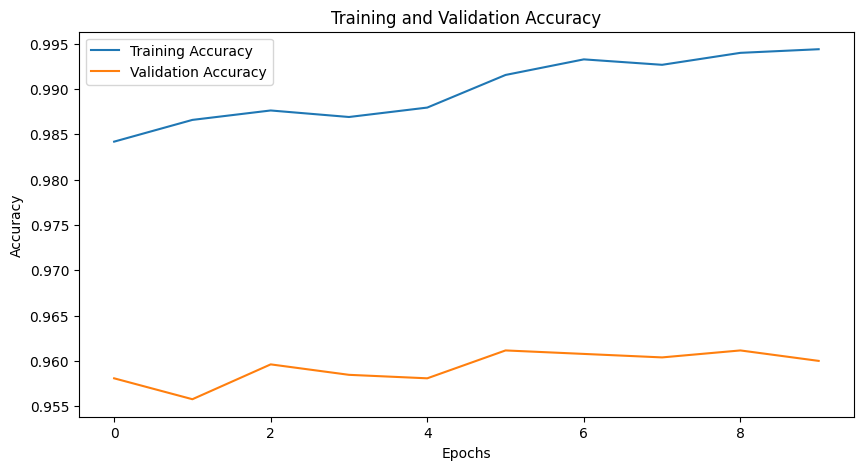

In [18]:

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


In [19]:

# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_data)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


82/82 [==============================] - 12s 149ms/step - loss: 0.1632 - accuracy: 0.9600
Test Loss: 0.16319012641906738
Test Accuracy: 0.9599999785423279


In [20]:

# Retrieve the accuracy from the training history
test_accuracy = history.history['val_accuracy']
print("Test Accuracy from History:", test_accuracy[-1])

Test Accuracy from History: 0.9599999785423279


In [21]:

# Make predictions on the test data
y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)  # Convert predicted probabilities to class labels

82/82 [==============================] - 12s 148ms/step


In [22]:
# Get true labels
y_true = test_data.classes


In [23]:

# Compute precision, recall, and F1 score
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.52      0.51      0.51      1300
           1       0.52      0.53      0.52      1300

    accuracy                           0.52      2600
   macro avg       0.52      0.52      0.52      2600
weighted avg       0.52      0.52      0.52      2600

